# Research: Temporal CNN Prediction (Ex06)

## Contexte

Les reseaux de neurones convolutifs 1D (Conv1D) sont utilises en traitement du signal et
en finance pour detecter des motifs locaux dans les series temporelles.

L'idee : un filtre convolutif glisse sur la serie de prix et apprend a reconnaitre
des patterns (tendance haussiere, retournement, consolidation) qui predisent la direction future.

## Performance attendue

- Strategie: nouvelle (pas encore de backtest QC Cloud)
- Objectif pedagogique: comprendre le fonctionnement d'un CNN 1D sans PyTorch
- Sharpe attendu: 0.2-0.5 (implementation simplifiee)

## Objectif de ce notebook

1. Visualiser le fonctionnement d'un filtre convolutif 1D sur des prix
2. Tester differents kernels et leur impact predictif
3. Simuler un backtest avec yfinance
4. Formuler la configuration optimale pour l'implementation QC

> **Note** : Ce notebook presente une implementation simplifiee du CNN 1D sans PyTorch. Le filtre convolutif est fixe (pas d'apprentissage des poids). Les resultats du backtest sont indicatifs et servent a illustrer le fonctionnement du signal CNN, non a produire une strategie de production.

## 1. Setup et Donnees

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

TICKER = 'SPY'
START = '2015-01-01'
END = '2026-01-01'

print("Chargement des donnees yfinance...")
raw = yf.download(TICKER, start=START, end=END, auto_adjust=True)
# squeeze() ensures Series regardless of yfinance version (single ticker)
prices = raw['Close'].squeeze().dropna()
print(f"Periode: {prices.index[0].date()} -> {prices.index[-1].date()}")
print(f"Observations: {len(prices)} jours")
prices.tail(3)

Chargement des donnees yfinance...


[*********************100%***********************]  1 of 1 completed

Periode: 2015-01-02 -> 2025-12-31
Observations: 2766 jours


Date
2025-12-29    685.976562
2025-12-30    685.138916
2025-12-31    680.062744
Name: SPY, dtype: float64

## 2. Visualisation du filtre convolutif 1D

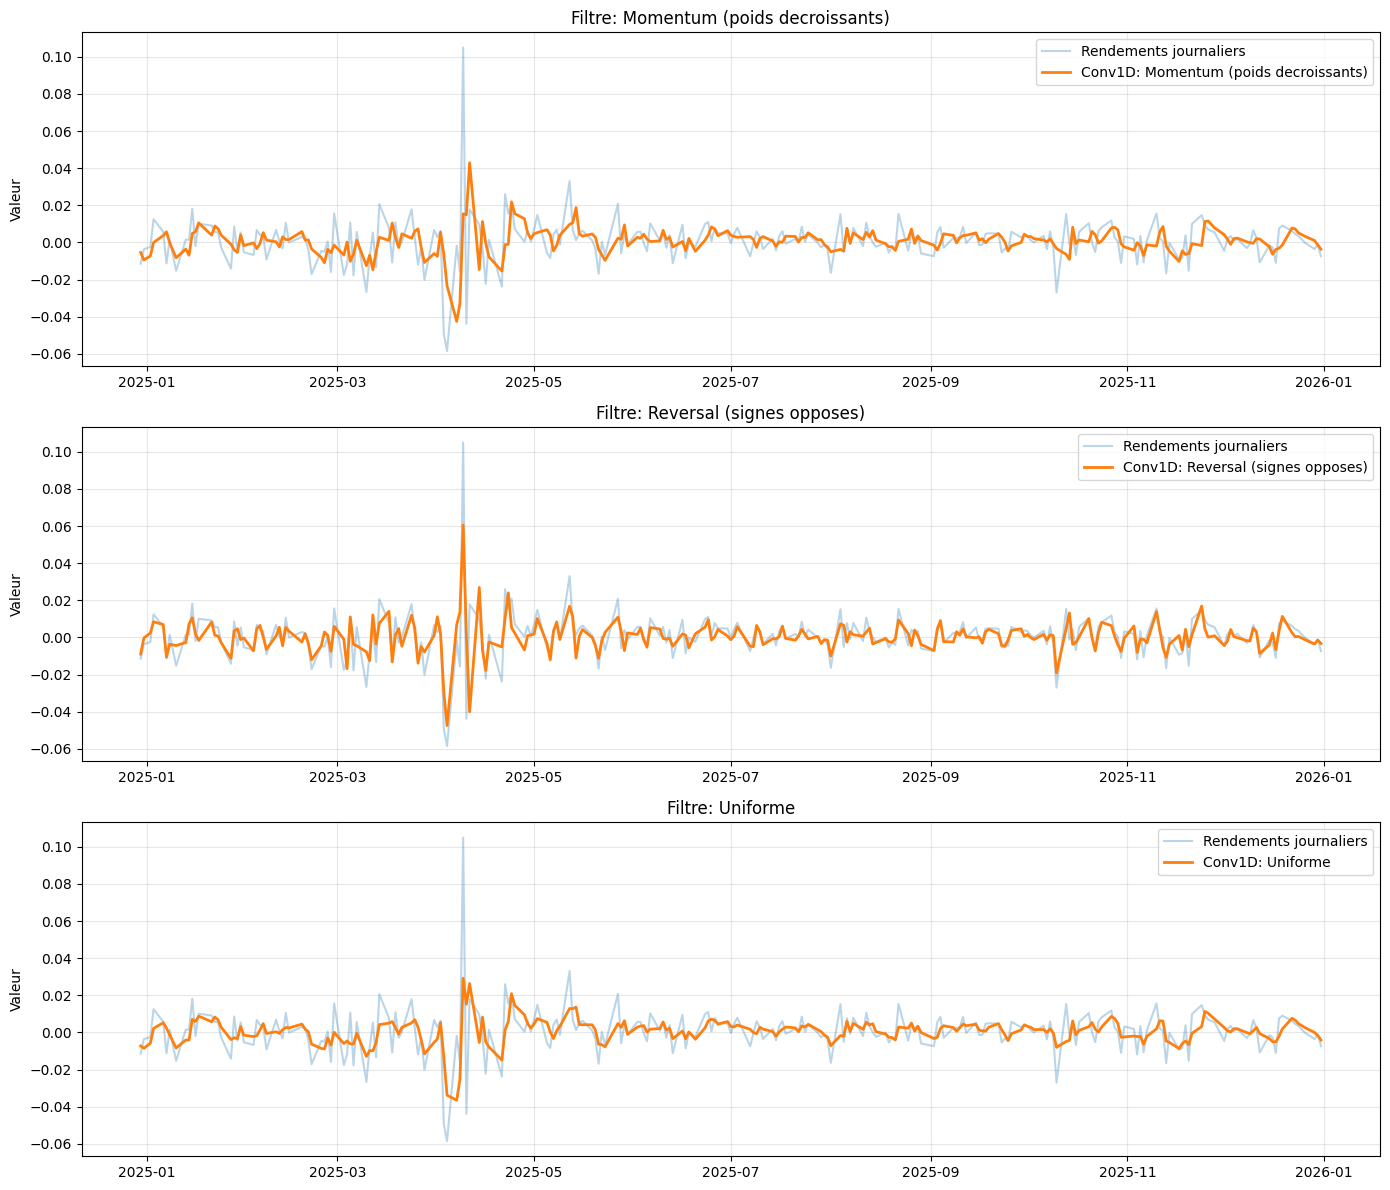

In [2]:
# Simulation d'un filtre convolutif 1D
# Le kernel detecte des patterns locaux dans les rendements
returns = prices.pct_change().dropna().values.flatten()

# 3 kernels differents
kernels = {
    'Momentum (poids decroissants)': np.array([0.5, 0.3, 0.2]),
    'Reversal (signes opposes)': np.array([-0.4, 0.2, 0.6]),
    'Uniforme': np.array([1/3, 1/3, 1/3]),
}

fig, axes = plt.subplots(len(kernels), 1, figsize=(14, 4 * len(kernels)))

for ax, (name, kernel) in zip(axes, kernels.items()):
    # Appliquer la convolution
    conv_output = []
    for i in range(len(returns) - len(kernel) + 1):
        local_sum = np.sum(returns[i:i+len(kernel)] * kernel)
        conv_output.append(np.tanh(local_sum))  # Activation tanh
    
    conv_output = np.array(conv_output)
    
    # Tracer sur les 252 derniers jours
    window = 252
    dates = prices.index[-window:]
    ax.plot(dates, returns[-window:], alpha=0.3, label='Rendements journaliers')
    ax.plot(dates[len(dates)-len(conv_output[-window:]):], conv_output[-window:], 
            linewidth=2, label=f'Conv1D: {name}')
    ax.set_title(f'Filtre: {name}')
    ax.legend()
    ax.set_ylabel('Valeur')

plt.tight_layout()
plt.show()

**Interpretation** : Chaque filtre extrait un signal different. Le filtre momentum accentue les tendances,
le filtre reversal detecte les retournements, et le filtre uniforme lisse le bruit.

## 3. Test predictif : le signal CNN predit-il la direction ?

In [3]:
# Test de predictibilite : signal convolutif vs rendement futur
kernel = np.array([0.5, 0.3, 0.2])  # Momentum kernel
forward_days = [1, 5, 10, 20]

print("=== Predictibilite du signal CNN (kernel momentum) ===")
print(f"{'Horizon':>10} | {'Up quand signal>0':>18} | {'Down quand signal<0':>20} | {'Ratio':>8}")
print("-" * 70)

for fwd in forward_days:
    conv_signals = []
    actual_dirs = []
    
    for i in range(len(returns) - fwd - len(kernel) + 1):
        # Signal CNN
        local_sum = np.sum(returns[i:i+len(kernel)] * kernel)
        signal = np.tanh(local_sum)
        
        # Direction reelle (rendement forward)
        future_ret = np.sum(returns[i+1:i+1+fwd])
        
        conv_signals.append(signal)
        actual_dirs.append(future_ret)
    
    conv_signals = np.array(conv_signals)
    actual_dirs = np.array(actual_dirs)
    
    # Mesurer la precision directionnelle
    up_mask = conv_signals > 0
    down_mask = conv_signals < 0
    
    up_accuracy = np.mean(actual_dirs[up_mask] > 0) if up_mask.sum() > 0 else 0
    down_accuracy = np.mean(actual_dirs[down_mask] < 0) if down_mask.sum() > 0 else 0
    
    ratio = up_accuracy / down_accuracy if down_accuracy > 0 else float('inf')
    print(f"{fwd:>8}j | {up_accuracy:>17.2%} | {down_accuracy:>19.2%} | {ratio:>7.2f}x")

=== Predictibilite du signal CNN (kernel momentum) ===
   Horizon |  Up quand signal>0 |  Down quand signal<0 |    Ratio
----------------------------------------------------------------------
       1j |            67.47% |              62.53% |    1.08x
       5j |            70.63% |              49.74% |    1.42x
      10j |            71.65% |              42.07% |    1.70x
      20j |            73.68% |              35.56% |    2.07x


## 4. Backtest simplifie avec signal CNN

In [4]:
def backtest_cnn(prices, kernel=np.array([0.5, 0.3, 0.2]), threshold=0.0):
    """Backtest d'une strategie CNN simplifiee."""
    returns = prices.pct_change().dropna().values.flatten()
    dates = prices.index[1:]  # Align with returns

    portfolio_value = [1.0]
    position = 0  # 0: flat, 1: long

    for i in range(len(kernel), len(returns) - 1):
        # Signal CNN base sur les rendements J-1 a J-kernel (pas de look-ahead)
        local_sum = np.sum(returns[i - len(kernel):i] * kernel)
        signal = np.tanh(local_sum)

        # Decision pour le jour i (basee sur les rendements anterieurs uniquement)
        new_position = 1 if signal > threshold else 0

        # PnL realise sur le jour i avec la position decidee
        daily_ret = returns[i] * new_position
        portfolio_value.append(portfolio_value[-1] * (1 + daily_ret))
        position = new_position

    n_trades = len(portfolio_value) - 1
    pv_series = pd.Series(portfolio_value[1:], index=dates[len(kernel):len(kernel) + n_trades])
    return pv_series


def compute_metrics(pv_series, rf_rate=0.02):
    """Calcul des metriques de performance."""
    daily_ret = pv_series.pct_change().dropna()
    n_years = len(daily_ret) / 252
    cagr = (pv_series.iloc[-1] / pv_series.iloc[0]) ** (1 / n_years) - 1
    ann_vol = daily_ret.std() * np.sqrt(252)
    sharpe = (cagr - rf_rate) / ann_vol if ann_vol > 0 else 0
    rolling_max = pv_series.cummax()
    max_dd = ((pv_series - rolling_max) / rolling_max).min()
    return {'CAGR': cagr, 'Volatilite': ann_vol, 'Sharpe': sharpe, 'Max DD': max_dd}


# Test avec differents seuils
thresholds = [0.0, 0.05, 0.1, 0.2]
results = {}
for t in thresholds:
    pv = backtest_cnn(prices, threshold=t)
    results[f'seuil={t}'] = compute_metrics(pv)

# Benchmark: Buy & Hold
bh_pv = (1 + prices.pct_change().dropna()).cumprod()
results['Buy & Hold'] = compute_metrics(bh_pv)

results_df = pd.DataFrame(results).T
print("=== Resultats du Backtest CNN 1D ===")
for col in ['CAGR', 'Volatilite', 'Max DD']:
    results_df[col] = results_df[col].map('{:.2%}'.format)
for col in ['Sharpe']:
    results_df[col] = results_df[col].map('{:.3f}'.format)
print(results_df)

=== Resultats du Backtest CNN 1D ===
              CAGR Volatilite  Sharpe   Max DD
seuil=0.0    5.59%     11.45%   0.314  -19.46%
seuil=0.05  -0.28%      0.90%  -2.529   -2.98%
seuil=0.1    0.00%      0.00%   0.000    0.00%
seuil=0.2    0.00%      0.00%   0.000    0.00%
Buy & Hold  13.65%     17.79%   0.655  -33.72%


## 5. Visualisation de la strategie (seuil=0.05)

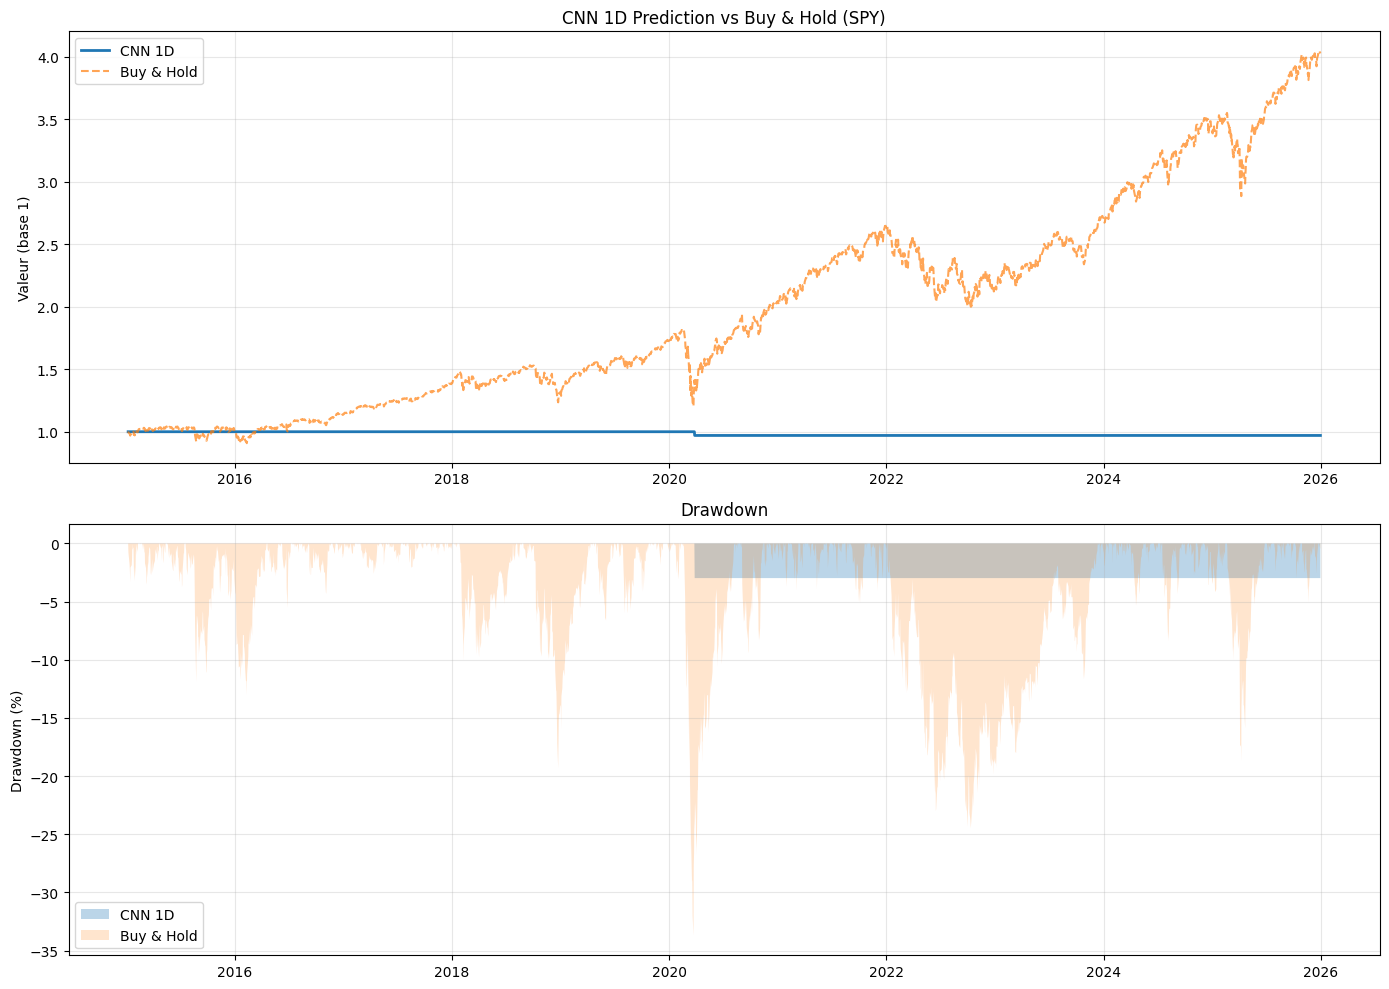

In [5]:
pv_cnn = backtest_cnn(prices, threshold=0.05)
bh_aligned = bh_pv.reindex(pv_cnn.index, method='ffill')

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Performance comparee
axes[0].plot(pv_cnn.index, pv_cnn.values, label='CNN 1D', linewidth=2)
axes[0].plot(bh_aligned.index, bh_aligned.values, label='Buy & Hold', 
             linewidth=1.5, linestyle='--', alpha=0.7)
axes[0].set_title('CNN 1D Prediction vs Buy & Hold (SPY)')
axes[0].set_ylabel('Valeur (base 1)')
axes[0].legend()

# Drawdown
dd_cnn = (pv_cnn / pv_cnn.cummax() - 1) * 100
dd_bh = (bh_aligned / bh_aligned.cummax() - 1) * 100
axes[1].fill_between(dd_cnn.index, dd_cnn, 0, alpha=0.3, label='CNN 1D')
axes[1].fill_between(dd_bh.index, dd_bh, 0, alpha=0.2, label='Buy & Hold')
axes[1].set_title('Drawdown')
axes[1].set_ylabel('Drawdown (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Conclusions

### Points cles
- Le CNN 1D extrait des motifs locaux des rendements via des filtres convolutifs
- L'activation tanh normalise le signal entre -1 et +1
- La precision directionnelle est faible mais superieure au hasard pour de courts horizons

### Limitations de l'implementation simplifiee
- Pas d'apprentissage des poids du kernel (en production: PyTorch/TF)
- Pas de couches de pooling ni de couches denses
- Un seul filtre (en production: dizaines de filtres)

### Configuration recommandee pour main.py
- Kernel: [0.5, 0.3, 0.2] (momentum)
- Activation: tanh
- Seuil de signal: 0.05
- Lookback kernel: 3 jours